# Hồi quy Logistic dưới góc nhìn Mạng nơ-ron (Logistic Regression with a Neural Network Mindset)

Chào mừng bạn đến với bài tập lập trình đầu tiên. Bạn sẽ xây dựng một bộ phân loại hồi quy logistic (Logistic Regression Classifier) để nhận dạng mèo. Bài tập này sẽ hướng dẫn bạn từng bước cách thực hiện với tư duy mạng nơ-ron, đồng thời củng cố trực giác về học sâu (Deep Learning).

**Hướng dẫn:**
- Không sử dụng vòng lặp (`for`/`while`) trong mã nguồn, trừ khi đề bài yêu cầu rõ ràng.
- Sử dụng `np.dot(X, Y)` để tính tích vô hướng (dot product).

**Mục tiêu học tập:**
- Xây dựng kiến trúc tổng quát của một thuật toán học:
    - Khởi tạo tham số (Initializing parameters)
    - Tính toán hàm mất mát (Cost function) và đạo hàm (Gradients)
    - Sử dụng thuật toán tối ưu hóa Gradient Descent
- Kết hợp các hàm trên vào một mô hình hoàn chỉnh theo đúng thứ tự.

---

## Mục lục
- [1 - Thư viện](#1)
- [2 - Tổng quan về tập dữ liệu](#2)
    - [Bài tập 1 - Kích thước dữ liệu](#ex-1)
    - [Bài tập 2 - Reshape dữ liệu](#ex-2)
- [3 - Kiến trúc tổng quát của thuật toán học](#3)
- [4 - Xây dựng các thành phần của thuật toán](#4)
    - [4.1 - Hàm kích hoạt Sigmoid](#ex-3)
    - [4.2 - Khởi tạo tham số](#ex-4)
    - [4.3 - Lan truyền xuôi và Lan truyền ngược](#ex-5)
    - [4.4 - Tối ưu hóa Gradient Descent](#ex-6)
    - [4.5 - Hàm dự đoán](#ex-7)
- [5 - Tích hợp mô hình hoàn chỉnh](#ex-8)
- [6 - Phân tích sâu hơn & Lựa chọn Learning Rate](#6)
- [7 - Thử nghiệm với hình ảnh tùy chọn](#7)

## 1 - Các gói thư viện ##

Trước tiên, hãy chạy ô mã dưới đây để nhập tất cả các gói thư viện cần thiết cho bài tập này.
- [numpy](https://numpy.org/doc/1.20/) là gói thư viện nền tảng cho tính toán khoa học với Python.
- [h5py](http://www.h5py.org) là gói thư viện phổ biến dùng để thao tác với các tập dữ liệu được lưu trữ trong tệp H5.
- [matplotlib](http://matplotlib.org) là thư viện nổi tiếng dùng để vẽ đồ thị trong Python.
- [PIL](https://pillow.readthedocs.io/en/stable/) và [scipy](https://www.scipy.org/) được sử dụng ở đây để kiểm thử mô hình với hình ảnh của riêng bạn ở phần cuối bài tập.

In [1]:
import numpy as np
import copy 
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image
from scipy import ndimage
from lr_utils import load_dataset
from public_tests import *


<a name='2'></a>
## 2. Tổng quan về tập dữ liệu (Overview of the Problem Set)

**Mô tả bài toán:** Bộ dữ liệu (`data.h5`) bao gồm:
- Tập huấn luyện (train set) gồm `m_train` ảnh được gán nhãn mèo ($y=1$) hoặc không phải mèo ($y=0$).
- Tập kiểm thử (test set) gồm `m_test` ảnh được gán nhãn tương tự.
- Mỗi ảnh có kích thước `(num_px, num_px, 3)` tương ứng 3 kênh màu RGB (ảnh vuông).

In [2]:
# Tải dữ liệu (cat/non-cat)
train_set_x_orig , train_set_y , test_set_x_orig , test_set_y , classes = load_dataset()

Chúng tôi đã thêm hậu tố "_orig" vào tên các tập dữ liệu hình ảnh (tập huấn luyện và tập kiểm thử) vì chúng ta sẽ tiến hành tiền xử lý chúng. Sau khi tiền xử lý, ta sẽ thu được `train_set_x` và `test_set_x` (các nhãn `train_set_y` và `test_set_y` không cần qua bước tiền xử lý nào).

Mỗi dòng trong `train_set_x_orig` và `test_set_x_orig` là một mảng biểu diễn một hình ảnh. Bạn có thể xem hình ảnh minh họa bằng cách chạy đoạn mã dưới đây. Đừng ngần ngại thay đổi giá trị `index` và chạy lại để xem các hình ảnh khác.

y = [1], it's a 'cat' picture.
y = [0], it's a 'non-cat' picture.


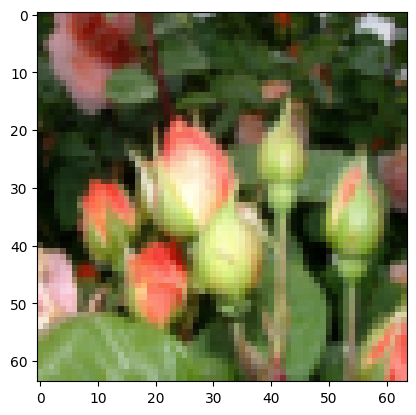

In [6]:
# Example of a picture
index1 = 24
plt.imshow(train_set_x_orig[index1])
print ("y = " + str(train_set_y[:, index1]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index1])].decode("utf-8") +  "' picture.")

index2 = 36
plt.imshow(train_set_x_orig[index2])
print ("y = " + str(train_set_y[:, index2]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index2])].decode("utf-8") +  "' picture.")

Nhiều lỗi phần mềm trong học sâu (deep learning) bắt nguồn từ việc kích thước ma trận hoặc vectơ không khớp nhau. Nếu kiểm soát tốt kích thước ma trận/vectơ, bạn sẽ loại bỏ được rất nhiều lỗi.

<a name='ex-1'></a>
### Bài tập 1
Xác định các giá trị sau:
- m_train (số lượng mẫu huấn luyện)
- m_test (số lượng mẫu kiểm thử)
- num_px (= chiều cao = chiều rộng của ảnh huấn luyện)
Hãy nhớ rằng `train_set_x_orig` là một mảng numpy có hình dạng (shape) là (m_train, num_px, num_px, 3). Ví dụ, bạn có thể lấy giá trị `m_train` bằng cách viết `train_set_x_orig.shape[0]`.

In [7]:
m_train=train_set_x_orig.shape[0]
m_test =test_set_x_orig.shape[0]
num_px=train_set_x_orig.shape[1]
print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("Height/Width of each image: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))


Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


Để thuận tiện, bây giờ bạn nên chuyển đổi hình dạng (reshape) các hình ảnh có kích thước (num_px, num_px, 3) thành một mảng numpy có kích thước (num_px $*$ num_px $*$ 3, ​​1). Sau bước này, tập dữ liệu huấn luyện (và kiểm thử) của chúng ta sẽ là một mảng numpy mà trong đó mỗi cột đại diện cho một hình ảnh đã được làm phẳng (flattened). Sẽ có m_train (tương ứng là m_test) cột.

<a name='ex-2'></a>
### Bài tập 2
Hãy chuyển đổi hình dạng của các tập dữ liệu huấn luyện và kiểm thử sao cho các hình ảnh có kích thước (num_px, num_px, 3) được làm phẳng thành các vectơ đơn lẻ có kích thước (num\_px $*$ num\_px $*$ 3, ​​1).

Một mẹo nhỏ khi bạn muốn làm phẳng một ma trận X có kích thước (a,b,c,d) thành ma trận X_flatten có kích thước (b$*$c$*$d, a) là sử dụng:
```python
X_flatten = X.reshape(X.shape[0], -1).T      # X.T là ma trận chuyển vị của X
```

In [ ]:
# Ở đây là đi làm phẳng từng ảnh , với train_set_x_orig.shape[0] là số ảnh đầu vào còn lại là dài , rộng và kênh
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[1]* train_set_x_orig.shape[2]*train_set_x_orig.shape[3] ,train_set_x_orig.shape[0])
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[1]*test_set_x_orig.shape[2]*test_set_x_orig.shape[3],test_set_x_orig.shape[0])
print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)


Để biểu diễn ảnh màu, các kênh đỏ, lục và lam (RGB) cần được xác định cho từng điểm ảnh (pixel); do đó, giá trị của điểm ảnh thực chất là một vectơ gồm ba số nằm trong khoảng từ 0 đến 255.

Một bước tiền xử lý phổ biến trong học máy là định tâm và chuẩn hóa tập dữ liệu; nghĩa là bạn trừ đi giá trị trung bình của toàn bộ mảng numpy khỏi mỗi mẫu dữ liệu, sau đó chia mẫu đó cho độ lệch chuẩn của toàn bộ mảng. Tuy nhiên, đối với các tập dữ liệu hình ảnh, việc chia mỗi hàng của tập dữ liệu cho 255 (giá trị tối đa của một kênh điểm ảnh) sẽ đơn giản, thuận tiện hơn và mang lại hiệu quả gần như tương đương.

Hãy cùng chuẩn hóa tập dữ liệu của chúng ta.

In [10]:
train_set_x = train_set_x_flatten / 255.
test_set_x = test_set_x_flatten / 255.

<a name='3'></a>
## 3 - Kiến trúc tổng quát của thuật toán học ##

Đã đến lúc thiết kế một thuật toán đơn giản để phân biệt hình ảnh có chứa mèo và hình ảnh không chứa mèo.

Bạn sẽ xây dựng một mô hình Hồi quy Logistic (Logistic Regression) dựa trên tư duy về Mạng Nơ-ron. Hình dưới đây giải thích lý do tại sao **Hồi quy Logistic thực chất chính là một Mạng Nơ-ron rất đơn giản!**

<img src="images/LogReg_kiank.png" style="width:650px;height:400px;">

**Biểu thức toán học của thuật toán**:

Đối với một mẫu dữ liệu $x^{(i)}$:
$$z^{(i)} = w^T x^{(i)} + b \tag{1}$$
$$\hat{y}^{(i)} = a^{(i)} = sigmoid(z^{(i)})\tag{2}$$
$$ \mathcal{L}(a^{(i)}, y^{(i)}) =  - y^{(i)}  \log(a^{(i)}) - (1-y^{(i)} )  \log(1-a^{(i)})\tag{3}$$

Sau đó, hàm chi phí (cost) được tính bằng cách lấy tổng trên tất cả các mẫu dữ liệu huấn luyện:
$$ J = \frac{1}{m} \sum_{i=1}^m \mathcal{L}(a^{(i)}, y^{(i)})\tag{6}$$

**Các bước chính**:
Trong bài tập này, bạn sẽ thực hiện các bước sau:
- Khởi tạo các tham số của mô hình
- Học các tham số cho mô hình bằng cách cực tiểu hóa hàm chi phí
- Sử dụng các tham số đã học để đưa ra dự đoán (trên tập kiểm thử)
- Phân tích kết quả và đưa ra kết luận

<a name='4'></a>
## 4 - Xây dựng các thành phần của thuật toán ##

Các bước chính để xây dựng một Mạng Nơ-ron bao gồm:
1. Xác định cấu trúc mô hình (ví dụ: số lượng đặc trưng đầu vào)
2. Khởi tạo các tham số của mô hình
3. Vòng lặp:
- Tính toán hàm mất mát hiện tại (lan truyền tiến - forward propagation)
- Tính toán gradient hiện tại (lan truyền ngược - backward propagation)
- Cập nhật các tham số (thuật toán hạ gradient - gradient descent)

Thông thường, bạn sẽ xây dựng riêng lẻ các bước từ 1 đến 3 và tích hợp chúng vào một hàm duy nhất có tên là `model()`.

<a name='4-1'></a>
### 4.1 - Các hàm hỗ trợ

<a name='ex-3'></a>
### Bài tập 3 - sigmoid
Hãy sử dụng đoạn mã từ phần "Python Basics" để triển khai hàm `sigmoid()`. Như đã thấy ở hình trên, bạn cần tính toán $sigmoid(z) = \frac{1}{1 + e^{-z}}$ với $z = w^T x + b$ để thực hiện dự đoán. Hãy sử dụng hàm np.exp().

In [12]:
def sigmoid(z):
    s = 1 / (1 + np.exp(-z))
    return s
print ("sigmoid([0, 2]) = " + str(sigmoid(np.array([0,2]))))

sigmoid_test(sigmoid)
x = np.array([0.5, 0, 2.0])
output = sigmoid(x)
print(output)

sigmoid([0, 2]) = [0.5        0.88079708]
All tests passed!
[0.62245933 0.5        0.88079708]


<a name='4-2'></a>
### 4.2 - Khởi tạo các tham số

<a name='ex-4'></a>
### Bài tập 4 - initialize_with_zeros
Hãy thực hiện việc khởi tạo tham số trong ô dưới đây. Bạn cần khởi tạo `w` là một vectơ gồm các số không. Nếu chưa biết sử dụng hàm nào của numpy, hãy tra cứu `np.zeros()` trong tài liệu của thư viện Numpy.

In [17]:
def initialize_with_zeros(dim):
    w = np.zeros((dim , 1))
    b = 0.0
    return w , b
dim =2 
w , b = initialize_with_zeros(dim)

assert type(b) == float
print ("w = " + str(w))
print ("b = " + str(b))

w = [[0.]
 [0.]]
b = 0.0


<a name='4-3'></a>
### 4.3 - Lan truyền tiến và lan truyền ngược

Sau khi đã khởi tạo các tham số, bạn có thể thực hiện các bước lan truyền tiến (forward propagation) và lan truyền ngược (backward propagation) để học các tham số này.

<a name='ex-5'></a>
### Bài tập 5 - propagate
Hãy cài đặt hàm `propagate()` để tính toán hàm chi phí (cost function) và đạo hàm (gradient) của nó.

**Gợi ý**:

Lan truyền tiến:
- Bạn nhận đầu vào là X
- Bạn tính $A = \sigma(w^T X + b) = (a^{(1)}, a^{(2)}, ..., a^{(m-1)}, a^{(m)})$
- Bạn tính hàm chi phí: $J = -\frac{1}{m}\sum_{i=1}^{m}(y^{(i)}\log(a^{(i)})+(1-y^{(i)})\log(1-a^{(i)}))$

Dưới đây là hai công thức bạn sẽ sử dụng:

$$ \frac{\partial J}{\partial w} = \frac{1}{m}X(A-Y)^T\tag{7}$$
$$ \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m (a^{(i)}-y^{(i)})\tag{8}$$

In [ ]:
def propagate(w, b, X, Y) :
    """
Triển khai hàm chi phí và gradient của nó cho quá trình lan truyền đã được giải thích ở trên

Các tham số:
w -- trọng số, một mảng numpy có kích thước (num_px * num_px * 3, 1)
b -- hệ số điều chỉnh (bias), một giá trị vô hướng
X -- dữ liệu có kích thước (num_px * num_px * 3, số lượng mẫu)
Y -- vectơ "nhãn" thực tế (chứa giá trị 0 nếu không phải mèo, 1 nếu là mèo) có kích thước (1, số lượng mẫu)

Giá trị trả về:
cost -- chi phí log-likelihood âm cho hồi quy logistic
dw -- gradient của hàm mất mát theo w, do đó có cùng hình dạng với w
db -- gradient của hàm mất mát theo b, do đó có cùng hình dạng với b

Gợi ý:
- Viết mã từng bước cho quá trình lan truyền. np.log(), np.dot()
"""

    m = X.shape[1]

# LAN TRUYỀN THUẬN (TỪ X ĐẾN COST)
#(≈ 2 dòng mã)
# tính toán giá trị kích hoạt (activation)
# A = ...
# tính toán chi phí bằng cách sử dụng np.dot để thực hiện phép nhân. 
# Và không sử dụng vòng lặp để tính tổng. 
# cost = ... 
    m = X.shape[1]
    A = sigmoid(np.dot(w.T , x) + b)
    cost = -1 * np.sum((Y * np.log(A) + (1-Y) * np.log(1-A)) /m)
    # BACKWARD PROPAGATION (TO FIND GRAD)
    #(≈ 2 lines of code)
    # dw = ...
    # db = ...
    dw = np.dot(X , (A-Y).T) / m
    db = np.sum(A - Y) / m
    cost = np.squeeze(np.array(cost))
    
    grads ={'dw:': dw , 'db:' : db}
    return grads , cost

In [ ]:
w = np.array([[1],[2]])
b =1.5
X = np.array([[1,-2,1],[3 , 0.5 , -3.2]]) # ở đây số hàng tương ứng với số đặc trưng , z = w_1 * x_1 + w_2 * x_2 + b
Y = np.array([[1,1,0]])
grads , cost = propagate(w, b, X, Y)
assert type(grads["dw"]) == np.ndarray
assert grads["dw"].shape == (2, 1)
assert type(grads["db"]) == np.float64


print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))

propagate_test(propagate)
